Global Cybersecurity Threats (2015-2024)

In [1]:
import pandas as pd

df = pd.read_csv('Global_Cybersecurity_Threats_2015-2024.csv')
df.head()


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


1 - Qual a "indústria" foi mais afetada pelos ataques ao longo dos anos, e qual foi o prejuizo financeiro de cada ano?

Indústria mais atacada: IT

Resumo anual:
      Ataques  Prejuízo (mi USD)
Year                            
2015       53            3000.21
2016       46            2073.90
2017       56            2551.06
2018       40            1940.38
2019       40            2089.18
2020       48            2735.03
2021       38            2440.71
2022       57            2842.01
2023       52            2635.80
2024       48            2501.55


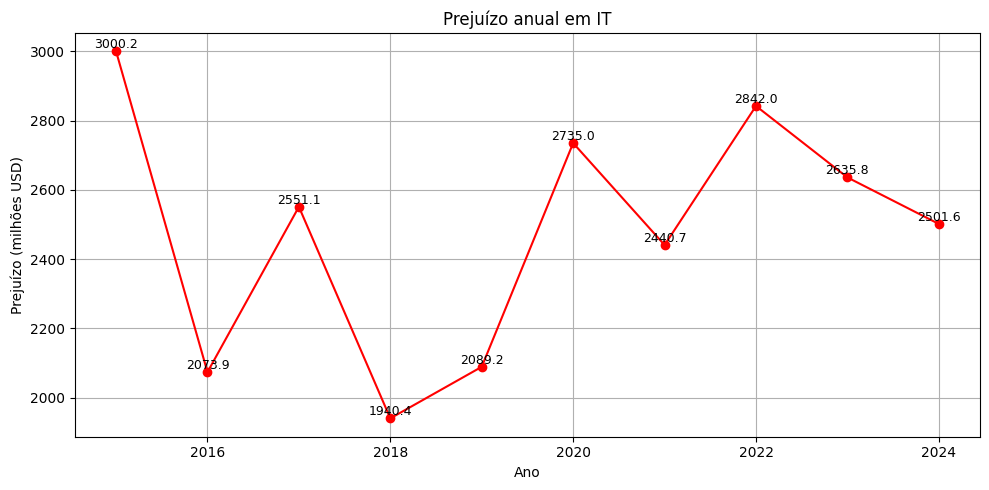

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
 
# Leitura dos dados
df = pd.read_csv('Global_Cybersecurity_Threats_2015-2024.csv')
df.columns = df.columns.str.strip()
 
# Remoção de registros incompletos nas colunas importantes
df = df.dropna(subset=['Target Industry', 'Year', 'Financial Loss (in Million $)'])
df['Year'] = df['Year'].astype(int)
 
# Descobrindo a indústria mais afetada
mais_afetada = df['Target Industry'].value_counts().idxmax()
print("Indústria mais atacada:", mais_afetada)
 
# Filtrando dados dessa indústria
dados = df[df['Target Industry'] == mais_afetada]
 
# Agrupamento por ano
resumo = dados.groupby('Year').agg({
    'Target Industry': 'count',
    'Financial Loss (in Million $)': 'sum'
}).rename(columns={
    'Target Industry': 'Ataques',
    'Financial Loss (in Million $)': 'Prejuízo (mi USD)'
})
 
print("\nResumo anual:")
print(resumo)
 
# Visualização
plt.figure(figsize=(10, 5))
plt.plot(resumo.index, resumo['Prejuízo (mi USD)'], marker='o', color='red')
plt.title(f'Prejuízo anual em {mais_afetada}')
plt.xlabel('Ano')
plt.ylabel('Prejuízo (milhões USD)')
plt.grid(True)
 
for ano, valor in resumo['Prejuízo (mi USD)'].items():
    plt.text(ano, valor, f'{valor:.1f}', ha='center', va='bottom', fontsize=9)
 
plt.tight_layout()
plt.show()

2 - Qual os 5 Países Mais Afetados por Ataques Cibernéticos (2015-2024)?

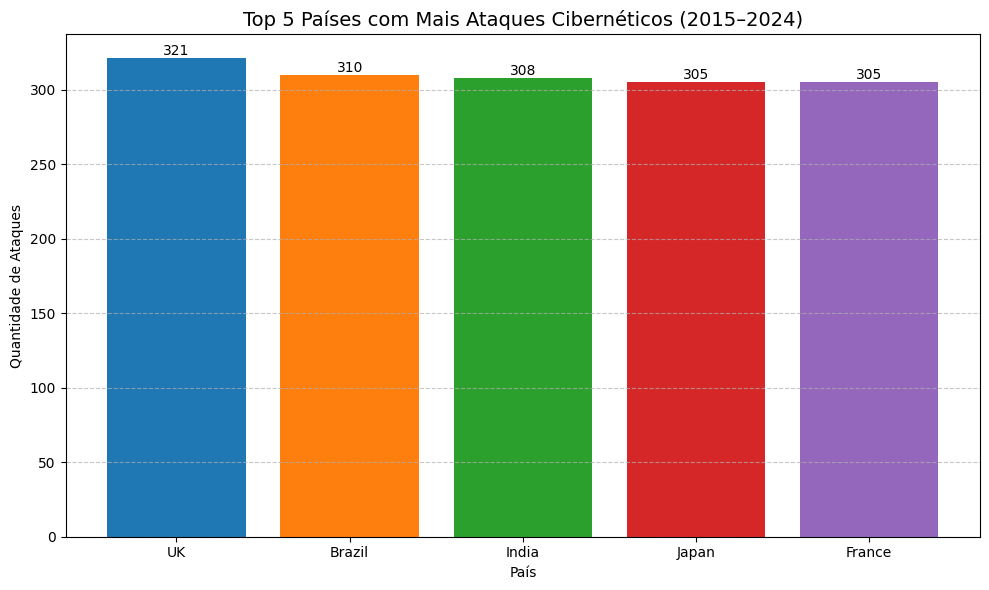

In [3]:
# Contagem de ataques por país
ataques_por_pais = df['Country'].value_counts()
 
# Seleciona os 5 países com mais registros
top_paises = ataques_por_pais.head(5)
 
# Gráfico
plt.figure(figsize=(10, 6))
cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
barras = plt.bar(top_paises.index, top_paises.values, color=cores)
 
plt.title('Top 5 Países com Mais Ataques Cibernéticos (2015–2024)', fontsize=14)
plt.xlabel('País')
plt.ylabel('Quantidade de Ataques')
plt.grid(axis='y', linestyle='--', alpha=0.7)
 
# Adiciona os números em cima das barras
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width() / 2, altura,
             f'{int(altura)}', ha='center', va='bottom')
 
plt.tight_layout()
plt.show()

3 - Qual o tipo de ataque mais utilizado, a quantidade de usuários afetados por este tipo de ataque, e qual vulnerabilidade mais exploradas neste tipo de ataque?

In [4]:
# Identifica o tipo de ataque mais utilizado
ataque_mais_comum = df['Attack Type'].value_counts().idxmax()
qtd_ataques = df['Attack Type'].value_counts().max()
 
# Soma de pessoas impactadas por esse tipo de ataque
afetados = df[df['Attack Type'] == ataque_mais_comum]['Number of Affected Users'].sum()
 
# Filtra os dados apenas para esse tipo de ataque
dados_ataque = df[df['Attack Type'] == ataque_mais_comum]
 
# Descobre o grupo mais vuneravel
vulnerabilidade = dados_ataque['Security Vulnerability Type'].value_counts().idxmax()
 
# Resultados
print(f"Tipo de ataque mais comum: {ataque_mais_comum} (Total: {qtd_ataques})")
print(f"Total de pessoas impactadas: {afetados}")
print(f"Vulnerabilidade mais explorada: {vulnerabilidade}")
plt.show()

Tipo de ataque mais comum: DDoS (Total: 531)
Total de pessoas impactadas: 265201265
Vulnerabilidade mais explorada: Weak Passwords


4 - Analisando o tipo de ataque mais comum utilizado pelos hackers, qual é o mecanismo de defesa mais eficiente contra esse tipo de ataque?

In [5]:
# Analisar a eficácia dos mecanismos de defesa
# Vamos assumir que menos "Incident Resolution Time" indica maior eficácia
# Agrupar pela defesa usada e calcular o tempo médio de resolução
avg_resolution_time = dados_ataque.groupby('Defense Mechanism Used')['Incident Resolution Time (in Hours)'].mean().reset_index()
 
# Ordenar pelo menor tempo de resolução (defesas mais eficazes primeiro)
mecanismo_defesa_mais_eficiente = avg_resolution_time.sort_values('Incident Resolution Time (in Hours)').iloc[0]
 
print(f"Mecanismo de defesa mais eficaz contra o ataque '{ataque_mais_comum}': {mecanismo_defesa_mais_eficiente['Defense Mechanism Used']}")
print(f"Tempo médio de resolução: {mecanismo_defesa_mais_eficiente['Incident Resolution Time (in Hours)']:.2f} horas")
 

Mecanismo de defesa mais eficaz contra o ataque 'DDoS': Firewall
Tempo médio de resolução: 32.33 horas


5 - Quais os paises que mais sofreram com ataques do tipo "Insider" (ataques de pessoas internas)?

In [6]:
# Filtra os registros de ataques realizados por insiders (pessoas de dentro da organização)
ataques_insider = df[df['Attack Source'].str.lower() == 'insider']
 
# Conta quantos ataques internos ocorreram em cada país
ataques_por_pais = (
    ataques_insider['Country']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'Country', 'Country': 'Qtd_Ataques_Insider'})
)
 
# Seleciona os 3 países com mais ocorrências
top3_paises = ataques_por_pais.head(3)
 
# Mostra o resultado
print("Top 3 países com maior número de ataques internos (insider):")
print(top3_paises)

Top 3 países com maior número de ataques internos (insider):
  Qtd_Ataques_Insider  count
0               India     88
1           Australia     81
2              Russia     80


6 - Quais os países mais afetados por ataques de Engenharia Social?

In [7]:
# Filtrar apenas os ataques do tipo "Social Engineering"
social_eng_df = df[df['Security Vulnerability Type'] == 'Social Engineering']

# Contar o número de ataques por país e ordenar em ordem decrescente
social_eng_counts = social_eng_df['Country'].value_counts().reset_index()
social_eng_counts.columns = ['País', 'Número de Ataques']

# Adicionar coluna de ranking
social_eng_counts['Ranking'] = range(1, len(social_eng_counts) + 1)
print("Paises mais afetados por ataques de Engenharia Social")
print(f"{'Ranking':<10}{'País':<20}{'Nº de Ataques':>15}")
print("------------------------------------------------")

for index, row in social_eng_counts.iterrows():
    print(f"{row['Ranking']:<10}{row['País']:<20}{row['Número de Ataques']:>15}")

Paises mais afetados por ataques de Engenharia Social
Ranking   País                  Nº de Ataques
------------------------------------------------
1         UK                               88
2         Brazil                           81
3         China                            78
4         France                           77
5         USA                              75
6         Japan                            74
7         Russia                           74
8         Australia                        70
9         Germany                          65
10        India                            65


7 - Quais os 5 países mais rápido na resolução de atauqes cibernéticos?

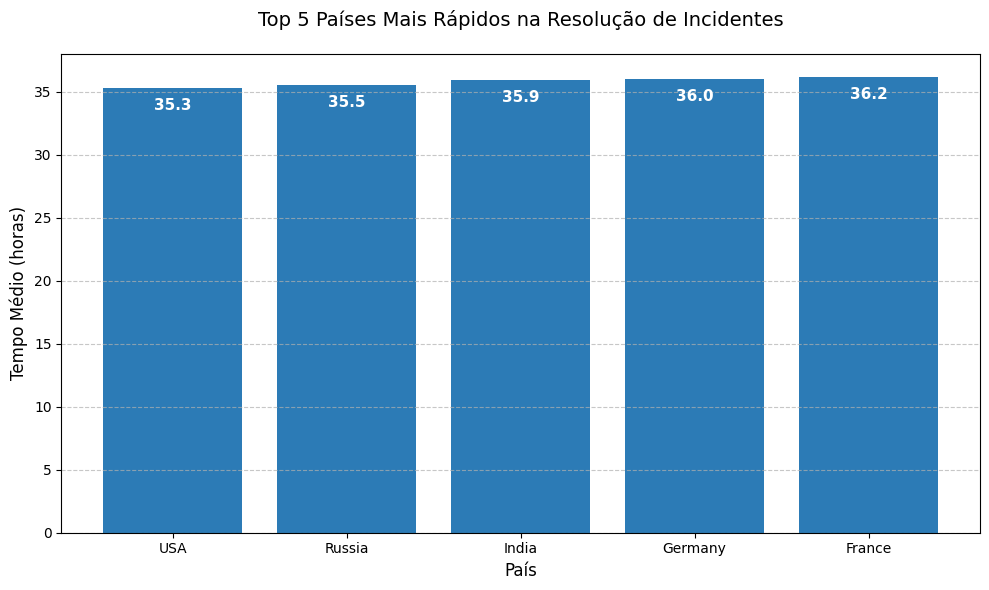

In [8]:
# Calcular a média do tempo de resolução por país e pegar os 5 mais rápidos
media = df.groupby('Country')['Incident Resolution Time (in Hours)'].mean()
top5 = media.sort_values().head(5)

# Configurações do gráfico
plt.figure(figsize=(10, 6))
bars = plt.bar(top5.index, top5.values, color='#2c7bb6')

# Personalização do gráfico
plt.title('Top 5 Países Mais Rápidos na Resolução de Incidentes', pad=20, fontsize=14)
plt.xlabel('País', fontsize=12)
plt.ylabel('Tempo Médio (horas)', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height-2,
             f'{height:.1f}',
             ha='center', va='bottom',
             color='white', fontsize=11, fontweight='bold')

# Melhorar a visualização
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Mostrar o gráfico
plt.show()

# Mostrar ranking em formato de tabela
#print("\nRanking dos 5 Países Mais Rápidos:")
#print("="*40)
#print(f"{'Posição':<10}{'País':<15}{'Média (horas)':>15}")
#print("-"*40)
#for i, (country, time) in enumerate(zip(top5.index, top5.values), 1):
#     print(f"{i:<10}{country:<15}{time:>15.2f}")


8 - Durante o periodo de 2018 até 2022 qual a porcentagem de cada ataques que o Brasil sofreu?

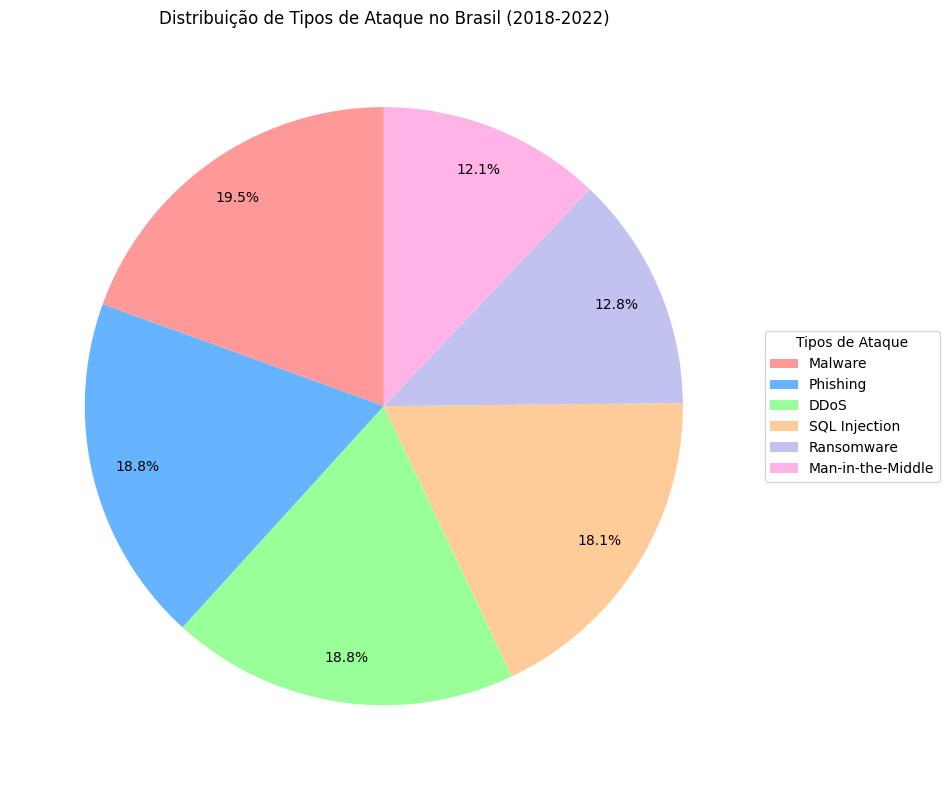

In [9]:
# Filtrar apenas ataques no Brasil entre 2018-2022
brasil_ataques = df[(df['Country'] == 'Brazil') & 
                    (df['Year'].between(2018, 2022))]

# Contar tipos de ataque
contagem_ataques = brasil_ataques['Attack Type'].value_counts()

# Configurar o gráfico de pizza
plt.figure(figsize=(10, 8))
cores = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6']

# Criar o gráfico
plt.pie(contagem_ataques, 
        labels=None,  # Removemos os labels do gráfico principal
        autopct='%1.1f%%',
        startangle=90,
        colors=cores,
        pctdistance=0.85)

# Adicionar legenda de cores
plt.legend(contagem_ataques.index, 
           title="Tipos de Ataque",
           loc="center left",
           bbox_to_anchor=(1, 0.5))

# Adicionar título
plt.title('Distribuição de Tipos de Ataque no Brasil (2018-2022)')

# Mostrar o gráfico
plt.tight_layout()
plt.show()

9 - É possível dizer que durante o périodo de pandemia (2020-2022) a quantidade de ataques aumentou na Alemanha? Se sim indique a porcentagem de aumento.

In [10]:
# Filtrar apenas dados da Alemanha
germany_df = df[df['Country'] == 'Germany']

# Definir períodos de análise
pre_pandemia = germany_df[germany_df['Year'].between(2015, 2019)]
durante_pandemia = germany_df[germany_df['Year'].between(2020, 2022)]

# Contar ataques em cada período
ataques_pre = len(pre_pandemia)
ataques_pandemia = len(durante_pandemia)

# Calcular variação
diferenca = ataques_pandemia - ataques_pre

# Evitar divisão por zero se não houver ataques no período pré-pandemia
if ataques_pre > 0:
    variacao_percentual = (diferenca / ataques_pre) * 100
else:
    variacao_percentual = float('inf')  # Caso não haja dados pré-pandemia

# Resultados
print("\nANÁLISE DE ATAQUES CIBERNÉTICOS NA ALEMANHA")
print("===========================================")
print(f"Período pré-pandemia (2015-2019): {ataques_pre} ataques")
print(f"Período da pandemia (2020-2022): {ataques_pandemia} ataques")
print("------------------------------------------------")

# Responder à pergunta
if ataques_pre == 0 and ataques_pandemia == 0:
    print("RESPOSTA: Não há registros de ataques para a Alemanha nos períodos analisados.")
elif ataques_pre == 0:
    print(f"RESPOSTA: Não há dados pré-pandemia, mas durante a pandemia houve {ataques_pandemia} ataques.")
elif diferenca > 0:
    print(f"RESPOSTA: Sim, houve aumento de {diferenca} ataques na Alemanha durante a pandemia.")
    print(f"Isso representa um aumento de {variacao_percentual:.1f}% em relação ao período anterior.")
elif diferenca < 0:
    print(f"RESPOSTA: Não, houve redução de {abs(diferenca)} ataques na Alemanha durante a pandemia.")
    print(f"Isso representa uma redução de {abs(variacao_percentual):.1f}% em relação ao período anterior.")
else:
    print("RESPOSTA: Não houve alteração na quantidade de ataques na Alemanha durante a pandemia.")

print("="*60)



ANÁLISE DE ATAQUES CIBERNÉTICOS NA ALEMANHA
Período pré-pandemia (2015-2019): 141 ataques
Período da pandemia (2020-2022): 88 ataques
------------------------------------------------
RESPOSTA: Não, houve redução de 53 ataques na Alemanha durante a pandemia.
Isso representa uma redução de 37.6% em relação ao período anterior.


10 - Entre as fontes de ataques "hacker group" e "insider" qual a fonte que proporcionou mais ataques

In [11]:
# Filtrar apenas os ataques de Hacker Groups e Insiders
attack_sources = df['Attack Source'].str.lower()
hacker_attacks = attack_sources.str.contains('hacker group').sum()
insider_attacks = attack_sources.str.contains('insider').sum()

# Resultados
print(f"Total de ataques por Hacker Groups: {hacker_attacks}")
print(f"Total de ataques por Insiders: {insider_attacks}")

if hacker_attacks > insider_attacks:
    print("\nHacker Groups são a fonte mais comum de ataques.")
elif insider_attacks > hacker_attacks:
    print("\nInsiders são a fonte mais comum de ataques.")
else:
    print("\nHacker Groups e Insiders têm a mesma quantidade de ataques.")

print("------------------------------------------------")
# Porcentagem
total = hacker_attacks + insider_attacks
print(f"Distribuição:")
print(f"- Hacker Groups: {(hacker_attacks/total)*100:.1f}%")
print(f"- Insiders: {(insider_attacks/total)*100:.1f}%")

Total de ataques por Hacker Groups: 686
Total de ataques por Insiders: 752

Insiders são a fonte mais comum de ataques.
------------------------------------------------
Distribuição:
- Hacker Groups: 47.7%
- Insiders: 52.3%
